# Phase 2e — 추가 전략 탐색 + Robustness

## 목적

Donchian / SMA+stop과 **트리거가 다른 전략 3개** (Keltner 변동성 돌파, Regime 필터, Z-score 평균회귀)를 BTC 4h에서 탐색한 뒤,  
B&H 낙폭 방어를 통과한 생존자에 한해 **robustness 3축**(OOS / 파라미터 민감도 / 워크포워드)을 BTC·ETH 양쪽에서 검증한다.

| 항목 | 내용 |
|---|---|
| 신규 전략 | KeltnerBreakout, RegimeFilter, ZScoreReversion |
| 참고 전략 (비교용) | DonchianBreakout, SmaCrossWithStop |
| 자산/시간단위 | BTC/USDT 4h, ETH/USDT 4h |
| 수수료 | 0.1% per side (하네스 고정) |

> **경고 — 탐색은 탐색이다.**  
> 탐색 단계 결과(A 섹션)는 같은 데이터로 여러 전략을 동시에 보는 스누핑(data snooping)을 포함한다.  
> **robustness 3축을 통과해야만 후보**로 인정하며, 탐색 숫자는 가설 생성용으로만 쓴다.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Some trades remain open at the end of backtest")
warnings.filterwarnings("ignore", message="Jupyter Notebook detected")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

import os, sys
if os.path.basename(os.getcwd()) == "research":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from backtest import load_data
from robustness import (train_test_split, evaluate,
                        param_sweep, walk_forward, buy_hold)
from strategies.keltner_breakout import KeltnerBreakout
from strategies.regime_filter import RegimeFilter
from strategies.zscore_reversion import ZScoreReversion
from strategies.donchian_breakout import DonchianBreakout
from strategies.sma_cross_stop import SmaCrossWithStop

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.1f}".format)

df_btc = load_data("BTC/USDT", "4h")
df_eth = load_data("ETH/USDT", "4h")
print(f"BTC: {len(df_btc)} bars  {df_btc.index[0].date()} ~ {df_btc.index[-1].date()}")
print(f"ETH: {len(df_eth)} bars  {df_eth.index[0].date()} ~ {df_eth.index[-1].date()}")

bh_btc = buy_hold(df_btc)
bh_eth = buy_hold(df_eth)
print(f"\nBTC B&H: 수익 {bh_btc['Return [%]']:+.1f}%  MDD {bh_btc['Max. Drawdown [%]']:+.1f}%")
print(f"ETH B&H: 수익 {bh_eth['Return [%]']:+.1f}%  MDD {bh_eth['Max. Drawdown [%]']:+.1f}%")

Loading BokehJS ...

BTC: 10949 bars  2021-06-28 ~ 2026-06-27
ETH: 10949 bars  2021-06-29 ~ 2026-06-28

BTC B&H: 수익 +75.3%  MDD -77.0%
ETH B&H: 수익 -27.6%  MDD -81.1%


---
## A. 탐색 (BTC 4h) — 6전략 비교

신규 3 + 참고 2, B&H 낙폭 방어(MDD) 여부로 검증 대상을 선별한다.  
**이 섹션은 가설 생성용이다 — 숫자 자체를 성과로 읽지 않는다.**

In [2]:
NEW = [("Keltner돌파", KeltnerBreakout), ("Regime필터", RegimeFilter), ("Z-score MR", ZScoreReversion)]
REF = [("[참고]Donchian", DonchianBreakout), ("[참고]SMA+stop", SmaCrossWithStop)]

rows = []
survivors = []
for name, strat in NEW + REF:
    m = evaluate(df_btc, strat)
    bh = bh_btc
    defend = m["Max. Drawdown [%]"] > bh["Max. Drawdown [%]"]
    is_new = name in [n for n, _ in NEW]
    if is_new and defend:
        survivors.append(name)
    rows.append({
        "전략": name,
        "Return%": round(m["Return [%]"], 1),
        "MDD%": round(m["Max. Drawdown [%]"], 1),
        "Sharpe": round(m["Sharpe Ratio"], 2),
        "Trades": int(m["# Trades"]),
        "B&H MDD%": round(bh["Max. Drawdown [%]"], 1),
        "방어(vs B&H)": "방어O" if defend else "방어X",
    })

tbl = pd.DataFrame(rows).set_index("전략")
display(tbl)
print(f"\n검증 대상 (신규 중 B&H 낙폭 방어): {survivors}")
print("=> Z-score MR 탈락: MR + 손절 5% 충돌 (가드레일5 통일 적용 결과 — 예상대로). 정상.")

,Return%,MDD%,Sharpe,Trades,B&H MDD%,방어(vs B&H)
전략,,,,,,
Keltner돌파,83.1,-37.3,0.5,116,-77.0,방어O
Regime필터,202.5,-34.9,0.6,143,-77.0,방어O
Z-score MR,-72.8,-78.1,-1.0,253,-77.0,방어X
[참고]Donchian,50.0,-45.7,0.2,150,-77.0,방어O
[참고]SMA+stop,45.4,-53.5,0.2,123,-77.0,방어O



검증 대상 (신규 중 B&H 낙폭 방어): ['Keltner돌파', 'Regime필터']
=> Z-score MR 탈락: MR + 손절 5% 충돌 (가드레일5 통일 적용 결과 — 예상대로). 정상.


---
## B. Keltner 돌파 — Robustness 3축

생존자 1: **KeltnerBreakout** (EMA ± ATR 밴드 돌파, 기본값: ema_n=20, atr_mult=2.0)  
BTC → ETH 순으로 3축 검증. 탈락 기준(사전 고정):
1. **OOS**: OOS 구간 MDD가 B&H보다 작아야 함 (낙폭 방어 재현)
2. **파라미터 민감도**: 이웃 조합 ≥60%가 B&H 낙폭 방어
3. **워크포워드**: 5구간 중 ≥3구간에서 낙폭 방어

In [3]:
# ── 축1: OOS 헬퍼 ─────────────────────────────────────────────────────────
def make_oos_table(df, strategy, **params):
    train, test = train_test_split(df, 0.7)
    rows = []
    for label, d in [
        (f"FULL ({df.index[0].date()}~{df.index[-1].date()})", df),
        (f"IS 앞70% ({df.index[0].date()}~{train.index[-1].date()})", train),
        (f"OOS 뒤30% ({test.index[0].date()}~{test.index[-1].date()})", test),
    ]:
        m = evaluate(d, strategy, **params)
        bh = buy_hold(d)
        rows.append({
            "구간": label,
            "봉수": len(d),
            "전략 수익%": round(m["Return [%]"], 1),
            "전략 MDD%": round(m["Max. Drawdown [%]"], 1),
            "Sharpe": round(m["Sharpe Ratio"], 2),
            "B&H 수익%": round(bh["Return [%]"], 1),
            "B&H MDD%": round(bh["Max. Drawdown [%]"], 1),
            "낙폭방어%p": round(bh["Max. Drawdown [%]"] - m["Max. Drawdown [%]"], 1),
        })
    return pd.DataFrame(rows).set_index("구간")

# ── 축3: 워크포워드 헬퍼 ──────────────────────────────────────────────────
def make_wf_table(df, strategy, k=5, **params):
    wf = walk_forward(df, strategy, k=k, **params)
    rows = []
    for _, row in wf.iterrows():
        seg = df.loc[row["start"]:row["end"]]
        bh = buy_hold(seg)
        defend = row["Max. Drawdown [%]"] > bh["Max. Drawdown [%]"]
        rows.append({
            "구간": f"seg{int(row['segment'])}",
            "기간": f"{row['start'].date()}~{row['end'].date()}",
            "봉수": len(seg),
            "전략 수익%": round(row["Return [%]"], 1),
            "전략 MDD%": round(row["Max. Drawdown [%]"], 1),
            "Sharpe": round(row["Sharpe Ratio"], 2),
            "B&H 수익%": round(bh["Return [%]"], 1),
            "B&H MDD%": round(bh["Max. Drawdown [%]"], 1),
            "낙폭방어": "✓" if defend else "✗",
        })
    result = pd.DataFrame(rows).set_index("구간")
    defend_cnt = sum(1 for r in rows if r["낙폭방어"] == "✓")
    pos_cnt = sum(1 for r in rows if r["전략 수익%"] > 0)
    return result, defend_cnt, pos_cnt

# ── BTC Keltner 축1 OOS ───────────────────────────────────────────────────
print("=== Keltner 축1 OOS — BTC 4h ===")
kelt_btc_oos = make_oos_table(df_btc, KeltnerBreakout)
display(kelt_btc_oos)

print("\n=== Keltner 축1 OOS — ETH 4h ===")
kelt_eth_oos = make_oos_table(df_eth, KeltnerBreakout)
display(kelt_eth_oos)

=== Keltner 축1 OOS — BTC 4h ===


,봉수,전략 수익%,전략 MDD%,Sharpe,B&H 수익%,B&H MDD%,낙폭방어%p
구간,,,,,,,
FULL (2021-06-28~2026-06-27),10949,83.1,-37.3,0.5,75.3,-77.0,-39.8
IS 앞70% (2021-06-28~2024-12-26),7664,161.6,-25.1,0.9,178.1,-77.0,-51.9
OOS 뒤30% (2024-12-27~2026-06-27),3285,-30.0,-34.1,-1.5,-37.4,-52.7,-18.6



=== Keltner 축1 OOS — ETH 4h ===


,봉수,전략 수익%,전략 MDD%,Sharpe,B&H 수익%,B&H MDD%,낙폭방어%p
구간,,,,,,,
FULL (2021-06-29~2026-06-28),10949,103.3,-28.7,0.5,-27.6,-81.1,-52.4
IS 앞70% (2021-06-29~2024-12-27),7664,92.6,-28.7,0.6,52.8,-81.1,-52.4
OOS 뒤30% (2024-12-27~2026-06-28),3285,5.6,-27.7,0.1,-53.1,-68.0,-40.3


BTC Keltner sweep: 조합 16개 | 수익>0: 100% | B&H낙폭방어: 100%
=> 민감도 (>=60% 방어): OK



ETH Keltner sweep: 조합 16개 | 수익>0: 100% | B&H낙폭방어: 100%
=> 민감도 (>=60% 방어): OK


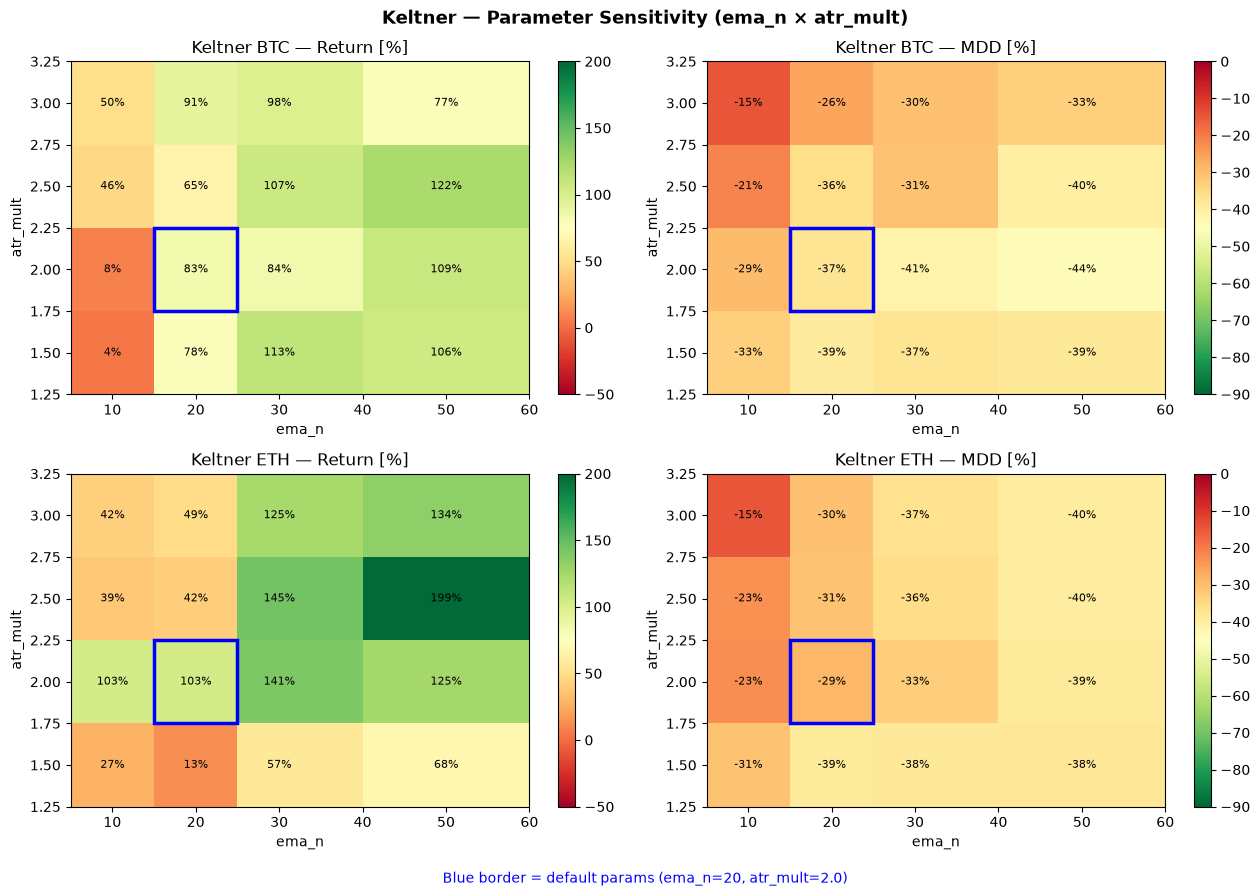

In [4]:
# ── BTC Keltner 축2 파라미터 민감도 (ema_n × atr_mult 히트맵) ─────────────
kelt_grid = {"ema_n": [10, 20, 30, 50], "atr_mult": [1.5, 2.0, 2.5, 3.0]}
kelt_btc_sweep = param_sweep(df_btc, KeltnerBreakout, kelt_grid)
kelt_btc_sweep["beats"] = kelt_btc_sweep["Max. Drawdown [%]"] > bh_btc["Max. Drawdown [%]"]
btc_def_rate = kelt_btc_sweep["beats"].mean() * 100
btc_pos_rate = (kelt_btc_sweep["Return [%]"] > 0).mean() * 100
print(f"BTC Keltner sweep: 조합 {len(kelt_btc_sweep)}개 | 수익>0: {btc_pos_rate:.0f}% | B&H낙폭방어: {btc_def_rate:.0f}%")
print(f"=> 민감도 (>=60% 방어): {'OK' if btc_def_rate >= 60 else 'FAIL'}")

kelt_eth_sweep = param_sweep(df_eth, KeltnerBreakout, kelt_grid)
kelt_eth_sweep["beats"] = kelt_eth_sweep["Max. Drawdown [%]"] > bh_eth["Max. Drawdown [%]"]
eth_def_rate = kelt_eth_sweep["beats"].mean() * 100
eth_pos_rate = (kelt_eth_sweep["Return [%]"] > 0).mean() * 100
print(f"\nETH Keltner sweep: 조합 {len(kelt_eth_sweep)}개 | 수익>0: {eth_pos_rate:.0f}% | B&H낙폭방어: {eth_def_rate:.0f}%")
print(f"=> 민감도 (>=60% 방어): {'OK' if eth_def_rate >= 60 else 'FAIL'}")

# 히트맵 (BTC Return, BTC MDD, ETH Return, ETH MDD)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Keltner — Parameter Sensitivity (ema_n × atr_mult)", fontsize=13, fontweight="bold")
DEFAULT_EMA, DEFAULT_MULT = 20, 2.0

for row_idx, (sweep, asset, bh_val) in enumerate([
    (kelt_btc_sweep, "BTC", bh_btc["Max. Drawdown [%]"]),
    (kelt_eth_sweep, "ETH", bh_eth["Max. Drawdown [%]"]),
]):
    for col_idx, (metric, cmap, vmin, vmax, label) in enumerate([
        ("Return [%]", "RdYlGn", -50, 200, "Return [%]"),
        ("Max. Drawdown [%]", "RdYlGn_r", -90, 0, "MDD [%]"),
    ]):
        pivot = sweep.pivot(index="atr_mult", columns="ema_n", values=metric)
        ax = axes[row_idx, col_idx]
        im = ax.pcolormesh(pivot.columns, pivot.index, pivot.values,
                           cmap=cmap, vmin=vmin, vmax=vmax)
        for mult in pivot.index:
            for ema in pivot.columns:
                val = pivot.loc[mult, ema]
                if not np.isnan(val):
                    ax.text(ema, mult, f"{val:.0f}%",
                            ha="center", va="center", fontsize=8, color="black")
        ax.set_xlabel("ema_n")
        ax.set_ylabel("atr_mult")
        ax.set_title(f"Keltner {asset} — {label}")
        plt.colorbar(im, ax=ax)
        # 기본값 표시
        ax.add_patch(mpatches.Rectangle(
            (DEFAULT_EMA - 5, DEFAULT_MULT - 0.25), 10, 0.5,
            linewidth=2.5, edgecolor="blue", facecolor="none", zorder=5
        ))

fig.text(0.5, 0.01, "Blue border = default params (ema_n=20, atr_mult=2.0)",
         ha="center", fontsize=10, color="blue")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

In [5]:
# ── BTC + ETH Keltner 축3 워크포워드 ──────────────────────────────────────
print("=== Keltner 축3 워크포워드 (5구간) — BTC 4h ===")
kelt_btc_wf, kelt_btc_def, kelt_btc_pos = make_wf_table(df_btc, KeltnerBreakout)
display(kelt_btc_wf)
print(f"  수익>0: {kelt_btc_pos}/5구간 | 낙폭방어: {kelt_btc_def}/5구간")
print(f"  => 워크포워드 (>=3구간 방어): {'OK' if kelt_btc_def >= 3 else 'FAIL'}")

print("\n=== Keltner 축3 워크포워드 (5구간) — ETH 4h ===")
kelt_eth_wf, kelt_eth_def, kelt_eth_pos = make_wf_table(df_eth, KeltnerBreakout)
display(kelt_eth_wf)
print(f"  수익>0: {kelt_eth_pos}/5구간 | 낙폭방어: {kelt_eth_def}/5구간")
print(f"  => 워크포워드 (>=3구간 방어): {'OK' if kelt_eth_def >= 3 else 'FAIL'}")

=== Keltner 축3 워크포워드 (5구간) — BTC 4h ===


,기간,봉수,전략 수익%,전략 MDD%,Sharpe,B&H 수익%,B&H MDD%,낙폭방어
구간,,,,,,,,
seg0,2021-06-28~2022-06-28,2189,27.8,-13.1,0.8,-39.0,-73.6,✓
seg1,2022-06-28~2023-06-28,2190,38.4,-21.4,1.0,47.1,-36.8,✓
seg2,2023-06-28~2024-06-27,2190,25.8,-18.4,0.7,101.2,-22.4,✓
seg3,2024-06-27~2025-06-27,2190,-0.5,-25.7,-0.0,73.7,-30.6,✓
seg4,2025-06-27~2026-06-27,2190,-18.9,-25.5,-1.5,-43.7,-52.7,✓


  수익>0: 3/5구간 | 낙폭방어: 5/5구간
  => 워크포워드 (>=3구간 방어): OK

=== Keltner 축3 워크포워드 (5구간) — ETH 4h ===


,기간,봉수,전략 수익%,전략 MDD%,Sharpe,B&H 수익%,B&H MDD%,낙폭방어
구간,,,,,,,,
seg0,2021-06-29~2022-06-29,2189,-13.2,-26.5,-0.6,-47.4,-81.1,✓
seg1,2022-06-29~2023-06-29,2190,41.9,-22.9,0.9,62.6,-46.2,✓
seg2,2023-06-29~2024-06-28,2190,18.6,-21.5,0.6,87.3,-29.4,✓
seg3,2024-06-28~2025-06-28,2190,23.9,-26.6,0.6,-29.5,-65.1,✓
seg4,2025-06-28~2026-06-28,2190,14.4,-27.7,0.5,-35.2,-68.0,✓


  수익>0: 4/5구간 | 낙폭방어: 5/5구간
  => 워크포워드 (>=3구간 방어): OK


---
## C. Regime 필터 — Robustness 3축

생존자 2: **RegimeFilter** (가격 > 장기 SMA → 보유, 아래 → 현금, 기본값: sma_n=200)  
단일 파라미터(sma_n)라 히트맵 대신 **막대/표**로 민감도 시각화.

In [6]:
# ── BTC + ETH Regime 축1 OOS ──────────────────────────────────────────────
print("=== Regime 축1 OOS — BTC 4h ===")
reg_btc_oos = make_oos_table(df_btc, RegimeFilter)
display(reg_btc_oos)

print("\n=== Regime 축1 OOS — ETH 4h ===")
reg_eth_oos = make_oos_table(df_eth, RegimeFilter)
display(reg_eth_oos)

=== Regime 축1 OOS — BTC 4h ===


,봉수,전략 수익%,전략 MDD%,Sharpe,B&H 수익%,B&H MDD%,낙폭방어%p
구간,,,,,,,
FULL (2021-06-28~2026-06-27),10949,202.5,-34.9,0.6,75.3,-77.0,-42.1
IS 앞70% (2021-06-28~2024-12-26),7664,265.9,-34.9,0.8,178.1,-77.0,-42.1
OOS 뒤30% (2024-12-27~2026-06-27),3285,-18.1,-31.8,-0.6,-37.4,-52.7,-20.9



=== Regime 축1 OOS — ETH 4h ===


,봉수,전략 수익%,전략 MDD%,Sharpe,B&H 수익%,B&H MDD%,낙폭방어%p
구간,,,,,,,
FULL (2021-06-29~2026-06-28),10949,104.8,-42.9,0.3,-27.6,-81.1,-38.2
IS 앞70% (2021-06-29~2024-12-27),7664,66.9,-42.9,0.3,52.8,-81.1,-38.2
OOS 뒤30% (2024-12-27~2026-06-28),3285,42.4,-41.1,0.5,-53.1,-68.0,-26.9


BTC Regime sweep: B&H낙폭방어 100% | => OK
ETH Regime sweep: B&H낙폭방어 100% | => OK


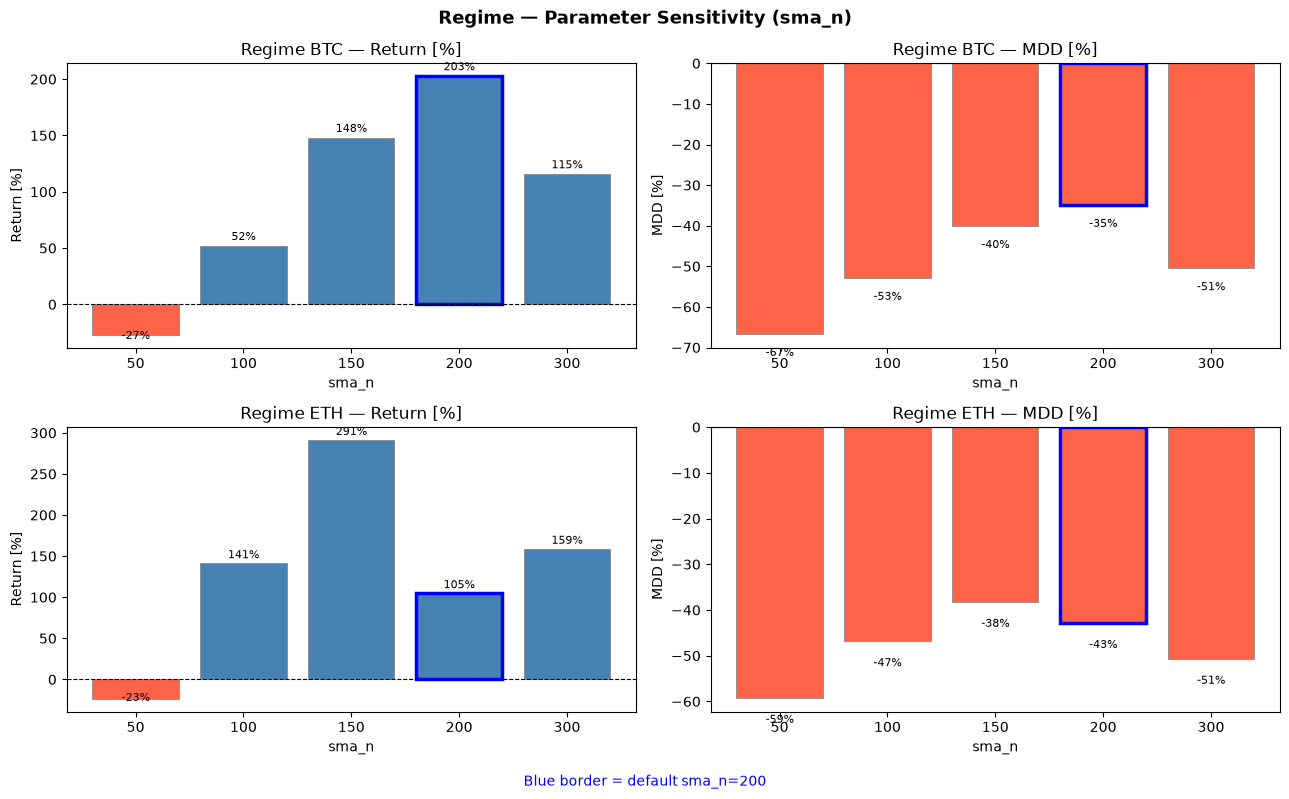


BTC Regime sweep 상세:


,sma_n,Return [%],Max. Drawdown [%],Sharpe Ratio,# Trades,beats
0,50,-27.0,-66.7,-0.2,380,True
1,100,51.8,-52.9,0.2,246,True
2,150,147.7,-40.2,0.5,183,True
3,200,202.5,-34.9,0.6,143,True
4,300,115.5,-50.5,0.4,107,True



ETH Regime sweep 상세:


,sma_n,Return [%],Max. Drawdown [%],Sharpe Ratio,# Trades,beats
0,50,-23.4,-59.3,-0.1,389,True
1,100,141.2,-46.9,0.3,229,True
2,150,291.2,-38.3,0.5,150,True
3,200,104.8,-42.9,0.3,142,True
4,300,158.7,-50.7,0.4,95,True


In [7]:
# ── BTC + ETH Regime 축2 파라미터 민감도 (sma_n 5값) ─────────────────────
reg_grid = {"sma_n": [50, 100, 150, 200, 300]}
reg_btc_sweep = param_sweep(df_btc, RegimeFilter, reg_grid)
reg_btc_sweep["beats"] = reg_btc_sweep["Max. Drawdown [%]"] > bh_btc["Max. Drawdown [%]"]
reg_eth_sweep = param_sweep(df_eth, RegimeFilter, reg_grid)
reg_eth_sweep["beats"] = reg_eth_sweep["Max. Drawdown [%]"] > bh_eth["Max. Drawdown [%]"]

btc_reg_def = reg_btc_sweep["beats"].mean() * 100
eth_reg_def = reg_eth_sweep["beats"].mean() * 100
print(f"BTC Regime sweep: B&H낙폭방어 {btc_reg_def:.0f}% | => {'OK' if btc_reg_def >= 60 else 'FAIL'}")
print(f"ETH Regime sweep: B&H낙폭방어 {eth_reg_def:.0f}% | => {'OK' if eth_reg_def >= 60 else 'FAIL'}")

# 막대 차트 시각화 (BTC / ETH 각각 Return, MDD)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Regime — Parameter Sensitivity (sma_n)", fontsize=13, fontweight="bold")
DEFAULT_SMA_N = 200

for row_idx, (sweep, asset) in enumerate([(reg_btc_sweep, "BTC"), (reg_eth_sweep, "ETH")]):
    for col_idx, (metric, ylabel, color_pos, color_neg) in enumerate([
        ("Return [%]", "Return [%]", "steelblue", "tomato"),
        ("Max. Drawdown [%]", "MDD [%]", "tomato", "tomato"),
    ]):
        ax = axes[row_idx, col_idx]
        vals = sweep[metric].values
        smas = sweep["sma_n"].values
        colors = [color_pos if v >= 0 else color_neg for v in vals]
        bars = ax.bar(range(len(smas)), vals, color=colors, edgecolor="gray", linewidth=0.5)
        ax.set_xticks(range(len(smas)))
        ax.set_xticklabels([str(s) for s in smas])
        ax.set_xlabel("sma_n")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Regime {asset} — {ylabel}")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        # 기본값 강조
        default_idx = list(smas).index(DEFAULT_SMA_N)
        bars[default_idx].set_edgecolor("blue")
        bars[default_idx].set_linewidth(2.5)
        for i, (bar, val) in enumerate(zip(bars, vals)):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    val + (3 if val >= 0 else -6),
                    f"{val:.0f}%", ha="center", va="bottom", fontsize=8)

fig.text(0.5, 0.01, "Blue border = default sma_n=200",
         ha="center", fontsize=10, color="blue")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

# 상세 표
print("\nBTC Regime sweep 상세:")
display(reg_btc_sweep[["sma_n", "Return [%]", "Max. Drawdown [%]", "Sharpe Ratio", "# Trades", "beats"]].round(1))
print("\nETH Regime sweep 상세:")
display(reg_eth_sweep[["sma_n", "Return [%]", "Max. Drawdown [%]", "Sharpe Ratio", "# Trades", "beats"]].round(1))

In [8]:
# ── BTC + ETH Regime 축3 워크포워드 ──────────────────────────────────────
print("=== Regime 축3 워크포워드 (5구간) — BTC 4h ===")
reg_btc_wf, reg_btc_def, reg_btc_pos = make_wf_table(df_btc, RegimeFilter)
display(reg_btc_wf)
print(f"  수익>0: {reg_btc_pos}/5구간 | 낙폭방어: {reg_btc_def}/5구간")
print(f"  => 워크포워드 (>=3구간 방어): {'OK' if reg_btc_def >= 3 else 'FAIL'}")

print("\n=== Regime 축3 워크포워드 (5구간) — ETH 4h ===")
reg_eth_wf, reg_eth_def, reg_eth_pos = make_wf_table(df_eth, RegimeFilter)
display(reg_eth_wf)
print(f"  수익>0: {reg_eth_pos}/5구간 | 낙폭방어: {reg_eth_def}/5구간")
print(f"  => 워크포워드 (>=3구간 방어): {'OK' if reg_eth_def >= 3 else 'FAIL'}")

=== Regime 축3 워크포워드 (5구간) — BTC 4h ===


,기간,봉수,전략 수익%,전략 MDD%,Sharpe,B&H 수익%,B&H MDD%,낙폭방어
구간,,,,,,,,
seg0,2021-06-28~2022-06-28,2189,9.5,-26.3,0.2,-39.0,-73.6,✓
seg1,2022-06-28~2023-06-28,2190,17.0,-23.6,0.4,47.1,-36.8,✓
seg2,2023-06-28~2024-06-27,2190,90.4,-16.2,1.1,101.2,-22.4,✓
seg3,2024-06-27~2025-06-27,2190,31.7,-27.4,0.7,73.7,-30.6,✓
seg4,2025-06-27~2026-06-27,2190,-23.2,-29.4,-1.4,-43.7,-52.7,✓


  수익>0: 4/5구간 | 낙폭방어: 5/5구간
  => 워크포워드 (>=3구간 방어): OK

=== Regime 축3 워크포워드 (5구간) — ETH 4h ===


,기간,봉수,전략 수익%,전략 MDD%,Sharpe,B&H 수익%,B&H MDD%,낙폭방어
구간,,,,,,,,
seg0,2021-06-29~2022-06-29,2189,-3.3,-40.3,-0.1,-47.4,-81.1,✓
seg1,2022-06-29~2023-06-29,2190,-26.6,-40.2,-0.8,62.6,-46.2,✓
seg2,2023-06-29~2024-06-28,2190,44.6,-32.2,0.7,87.3,-29.4,✗
seg3,2024-06-28~2025-06-28,2190,29.9,-26.6,0.5,-29.5,-65.1,✓
seg4,2025-06-28~2026-06-28,2190,-20.8,-41.1,-0.6,-35.2,-68.0,✓


  수익>0: 2/5구간 | 낙폭방어: 4/5구간
  => 워크포워드 (>=3구간 방어): OK


---
## 판정 + 정직한 한계

> 설계 문서 `docs/design/phase-2e-more-strategies.md` 결과/판정/정직한 한계 섹션 인용.

### 탐색 요약 (BTC 4h, B&H +75.3% / MDD -77.0%)

| 전략 | Return | MDD | Sharpe | Trades | B&H 방어 |
|---|---|---|---|---|---|
| **Keltner 돌파** | +83.1% | -37.3% | 0.46 | 116 | ✅ |
| **Regime 필터** | +202.5% | -34.9% | 0.56 | 143 | ✅ |
| Z-score MR | -72.8% | -78.1% | -1.02 | 253 | ❌ |
| (참고) Donchian | +50.0% | -45.7% | 0.24 | 150 | ✅ |
| (참고) SMA+stop | +45.4% | -53.5% | 0.22 | 123 | ✅ |

**Z-score MR 탈락**: MR + 손절 5% 충돌(가드레일5 통일 적용 결과, 예상대로). 정상.

### Robustness 결과 요약

| | OOS 방어 | 파라미터 민감도 | 워크포워드 | FULL |
|---|---|---|---|---|
| Keltner BTC | ✅ (OOS MDD -34.1 vs B&H -52.7) | ✅ 100% 방어·100% 양수 (16조합) | ✅ 5/5 | +83.1% / -37.3% |
| Keltner ETH | ✅ (OOS +5.6%·MDD -27.7 vs -68.0) | ✅ 100% 방어·100% 양수 | ✅ 5/5 | +103.3% / -28.7% |
| Regime BTC | ✅ (OOS MDD -31.8 vs -52.7) | ✅ 100% 방어 (sma 100~300 양수) | ✅ 5/5 | +202.5% / -34.9% |
| Regime ETH | ✅ (OOS +42.4%·MDD -41.1 vs -68.0) | ✅ 100% 방어 | ✅ 4/5 | +104.8% / -42.9% |

**→ Keltner·Regime 둘 다 BTC·ETH 견고성 3축 통과 → Phase 4 후보 추가.**  
(Regime ETH 워크포워드 4/5 — 기준 3/5 충족)

---

### ★ 정직한 한계 (과신 금지)

1. **B&H를 이긴 핵심 이유 = 이 5년에 2022 대폭락(-77%)이 들어있어서다.**  
   OOS(최근 18개월, 큰 폭락 없음)의 절대수익은 BTC에서 **음수** (Keltner -30%, Regime -18%) —  
   "폭락 없으면 B&H 못 이긴다"를 스스로 보여준다.  
   +202%를 미래 기대수익으로 읽으면 안 된다. **본질은 낙폭 방어 도구**.

2. **Keltner·Regime·Donchian·SMA+stop 4개 다 추세/돌파 계열 = 서로 상관 높음.**  
   후보가 4개여도 **분산된 포트폴리오가 아니다** (같이 오르고 같이 깨진다).  
   진짜 분산은 다른 엣지(선물 캐리, 횡단모멘텀 등)가 필요 — Phase 7 과제.

3. **2자산·단일 역사 경로 한계** 여전 (둘 다 크립토 베타).